In [101]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [102]:
# Read the CSV file in the same directory as the code
data = pd.read_csv('../data/The_Cancer_data_1500_V2.csv')
print("Dataset: ")
data.head()

Dataset: 


,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


In [103]:
# Separate features and target
X = data.drop(columns='Diagnosis')
y = data['Diagnosis']

# Split the data into training and testing sets (75% training, 25% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [104]:
# Define the parameter grid
param_grid = {
    'max_depth': [5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

In [105]:
# Output the best parameters found
# decision_tree = DecisionTreeClassifier(random_state=42)
# grid_search = GridSearchCV(estimator=decision_tree, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)
# grid_search.fit(X_train, y_train)
# print("Best parameters from wide grid search:", grid_search.best_params_)

In [106]:
# Define the parameter grid that has best 2 features
param_grid_adjusted = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4, 6, 10],
}

In [107]:
decision_tree = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator= decision_tree , param_grid=param_grid_adjusted, cv=5, n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

best_tree = grid_search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 6}


In [108]:
# Extract results from the grid search
cv_results = pd.DataFrame(grid_search.cv_results_)

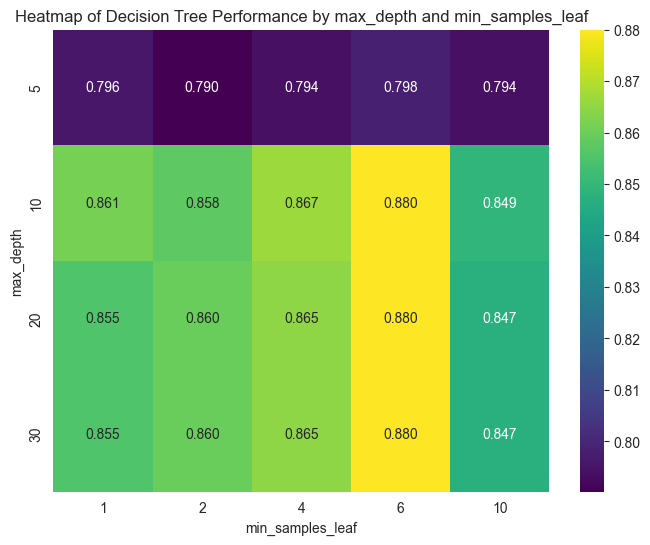

In [109]:
pivot_table = cv_results.pivot_table(values='mean_test_score',
                                     index='param_max_depth',
                                     columns='param_min_samples_leaf',)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt='.3f')
plt.title("Heatmap of Decision Tree Performance by max_depth and min_samples_leaf")
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.show()

The highest accuracy scores are observed when max_depth is set to 10, 20, or 30 and min_samples_leaf is set to 6, which leads to the highest performance. This indicates that a moderate to unrestricted level of depth control, combined with a minimum_sample_leaf set to 6 reduces overfitting by avoiding overly specific splits. In contrast, when max_depth is limited to 5, accuracy drops significantly across all values of min_samples_leaf. This lower depth appears to be too shallow for capturing the intricate patterns in the dataset, which might lead to underfitting.

Default Decision Tree Accuracy: 0.872
Tuned Decision Tree Accuracy: 0.872

Default Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90       233
           1       0.85      0.80      0.83       142

    accuracy                           0.87       375
   macro avg       0.87      0.86      0.86       375
weighted avg       0.87      0.87      0.87       375


Tuned Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90       233
           1       0.86      0.80      0.82       142

    accuracy                           0.87       375
   macro avg       0.87      0.86      0.86       375
weighted avg       0.87      0.87      0.87       375


<Figure size 1000x500 with 0 Axes>

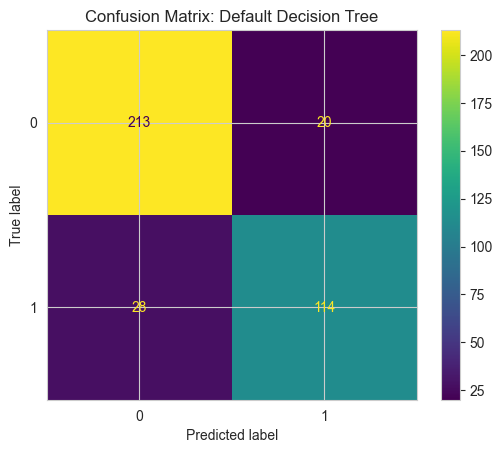

<Figure size 1000x500 with 0 Axes>

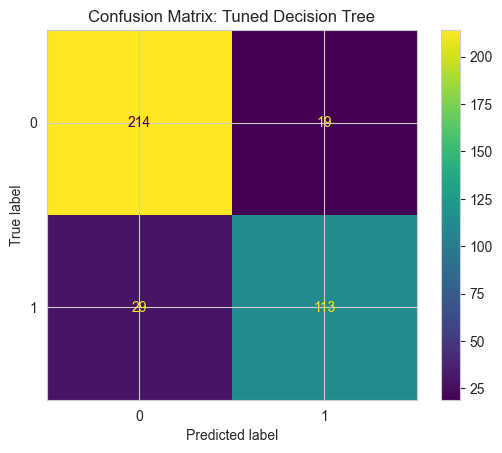

In [110]:
# Train and evaluate the default Decision Tree model
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_default_tree = tree.predict(X_test)

# Calculate metrics for default Decision Tree
accuracy = accuracy_score(y_test, y_pred_default_tree)
class_report = classification_report(y_test, y_pred_default_tree)

# Step 2: Train and evaluate the tuned Decision Tree model
best_tree = grid_search.best_estimator_
best_tree.fit(X_train, y_train)
y_pred_best_tree = best_tree.predict(X_test)

# Calculate metrics for tuned Decision Tree
accuracy_best_tree = accuracy_score(y_test, y_pred_best_tree)
classification_report_best_tree = classification_report(y_test, y_pred_best_tree)

print("Default Decision Tree Accuracy:", accuracy)
print("Tuned Decision Tree Accuracy:", accuracy_best_tree)
print("\nDefault Decision Tree Classification Report:\n", class_report)
print("\nTuned Decision Tree Classification Report:\n", classification_report_best_tree)

# Visualize confusion matrices
plt.figure(figsize=(10, 5))
ConfusionMatrixDisplay.from_estimator(tree, X_test, y_test)
plt.title("Confusion Matrix: Default Decision Tree")
plt.show()

plt.figure(figsize=(10, 5))
ConfusionMatrixDisplay.from_estimator(best_tree, X_test, y_test)
plt.title("Confusion Matrix: Tuned Decision Tree")
plt.show()


Background Information:

Precision is the proportion of correct positive predictions or:

$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$$

Recall is the proportion of of actual poisitives that were correctrly identified by the model:
$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives}+\text{False Positves}}$$

The tuned mode's accuracy improved slightly from 0.87 to 0.88. The F1-scores, which is a metric that balances precision and recall:
$$\text{F1 Score} = 2 \text{ x }\frac{\text{Precision x Recall}}{\text{Precision} + \text{Recall}}$$

**Analysis**
Based on the classification reports and confusion matrices for both the default and tuned Decision Tree models, it appears that hyperparameter tuning did not significantly improve performance. The accuracy for both the default and tuned Decision Tree models remained at 0.87. This lack of improvement suggests that the default parameters were already performing close to optimal for this dataset. Precision stayed at 0.88 for both models, meaning the rate of correctly identified negatives did not change with tuning.

For Class 0, precision remained unchanged. Recall increased slightly from 0.91 to 0.92 for Class 0, which resulted in a minor improvement in identifying true negatives. F1-score remained at 0.90, showing that the balance between precision and recall for Class 0 was nearly the same after tuning. For Class 1, Precision improved slightly from 0.85 to 0.86, which indicates a small reduction in false positives for the positive class. Recall remained unchanged at 0.80. F1-score for Class 1 decreased from 0.83 to 0.82, reflecting a negligible change in performance. These small changes suggest that tuning did not impact the model’s classification performance for either class in a meaningful way.

Furthermore, the Confusion Matrix made minor adjustments that did not lead to any significant improvement to the overall performance.

In [119]:
# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [121]:
# from sklearn.model_selection import RandomizedSearchCV
# 
# random_search_rf = RandomizedSearchCV(estimator=random_forest, param_distributions=param_grid_rf, n_iter=50, cv=5, n_jobs=-1, random_state=42, verbose=1, scoring='accuracy')
# random_search_rf.fit(X_train, y_train)
# 
# # Best parameters and score
# print("Best parameters from Randomized Search:", random_search_rf.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters from Randomized Search: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}


In [122]:
# Define the parameter grid for Random Forest
param_grid_rf = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

In [127]:
# Initialize the RandomForestClassifier
random_forest = RandomForestClassifier(random_state=42)

# Set up GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=random_forest, 
    param_grid=param_grid_rf, 
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all available cores
    verbose=1,  # Print progress
    scoring='accuracy'  # or another metric if desired
)

# Run the grid search
grid_search_rf.fit(X_train, y_train)

# Print the best parameters
print("Best parameters found by GridSearchCV:", grid_search_rf.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found by GridSearchCV: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}


Default Random Forest Accuracy: 0.9173333333333333
Tuned Random Forest Accuracy: 0.92
Default Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93       233
           1       0.92      0.86      0.89       142

    accuracy                           0.92       375
   macro avg       0.92      0.91      0.91       375
weighted avg       0.92      0.92      0.92       375

Tuned Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       233
           1       0.92      0.86      0.89       142

    accuracy                           0.92       375
   macro avg       0.92      0.91      0.91       375
weighted avg       0.92      0.92      0.92       375


<Figure size 800x600 with 0 Axes>

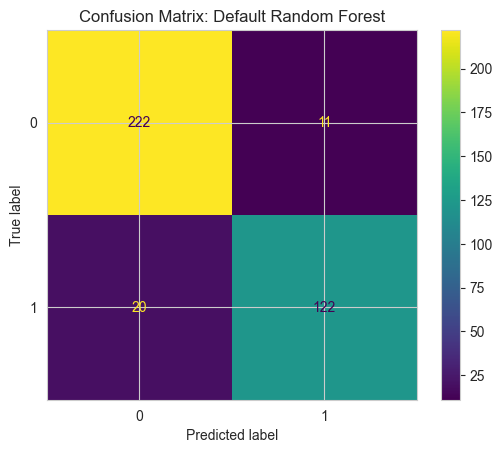

<Figure size 800x600 with 0 Axes>

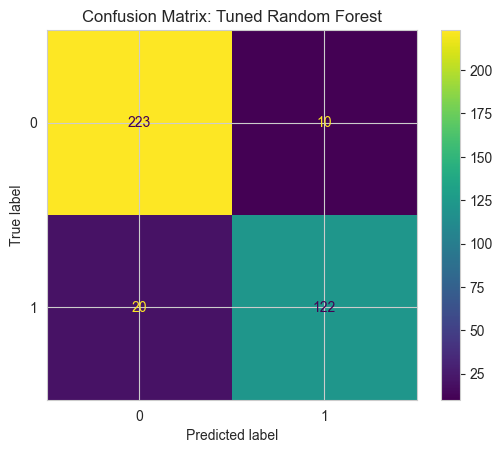

In [131]:
default_rf = RandomForestClassifier(random_state=42)
default_rf.fit(X_train, y_train)

# Make predictions with the default model
y_pred_default_rf = default_rf.predict(X_test)
accuracy_default_rf = accuracy_score(y_test, y_pred_default_rf)
classification_report_default_rf = classification_report(y_test, y_pred_default_rf)

# Hyperparameter tuning using GridSearchCV
random_forest = RandomForestClassifier(random_state=42)

# Retrieve the best model from GridSearchCV
best_rf = grid_search_rf.best_estimator_

# Make predictions with the tuned model
y_pred_best_rf = best_rf.predict(X_test)
accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
classification_report_best_rf = classification_report(y_test, y_pred_best_rf)

# Print and display results for the default and tuned model 
print("Default Random Forest Accuracy:", accuracy_default_rf)
print("Tuned Random Forest Accuracy:", accuracy_best_rf)

print("Default Random Forest Classification Report:\n", classification_report_default_rf)
print("Tuned Random Forest Classification Report:\n", classification_report_best_rf)

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(default_rf, X_test, y_test)
plt.title("Confusion Matrix: Default Random Forest")

plt.show()
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)
plt.title("Confusion Matrix: Tuned Random Forest")

plt.show()


The tuned model compared to the default model's accuracy increased from 91.73% to 92%. This suggests that hyperparameter tuning provided some benefit, although the improvement is relatively minor. In terms of recall, the tuned model exhibited a slight enhancement for Class 0, increasing from 0.95 to 0.96. This indicates a better ability to correctly identify negative cases. Consequently, this improvement in recall contributed to a minor increase in the F1-score for Class 0. For Class 1, there was a slight increase in precision from 0.92 to 0.93, yet both the recall and F1-score remained unchanged. The confusion matrices reflected these minor improvements, with the tuned model showing better performance in correctly identifying negative cases. However, overall, the changes are not substantial, and the default model already exhibited strong performance.

**Gender Analysis Decision Tree and Random Forest**

In [ ]:
male_data = data[data['Gender'] == 0]  # Male data
female_data = data[data['Gender'] == 1]  # Female data

Male Decision Tree Accuracy: 0.8743455497382199
Male Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       140
           1       0.76      0.76      0.76        51

    accuracy                           0.87       191
   macro avg       0.84      0.84      0.84       191
weighted avg       0.87      0.87      0.87       191


<Figure size 800x600 with 0 Axes>

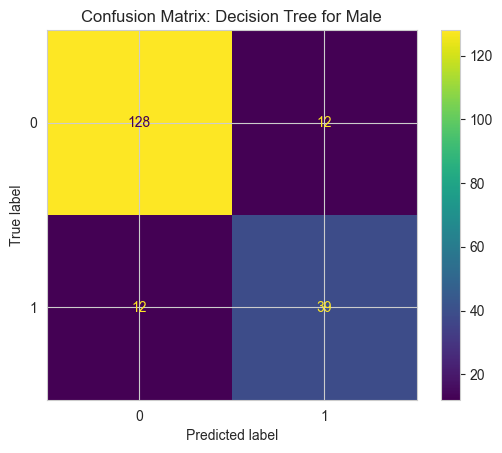

Female Decision Tree Accuracy: 0.8532608695652174
Female Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.85        91
           1       0.85      0.86      0.86        93

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184


<Figure size 800x600 with 0 Axes>

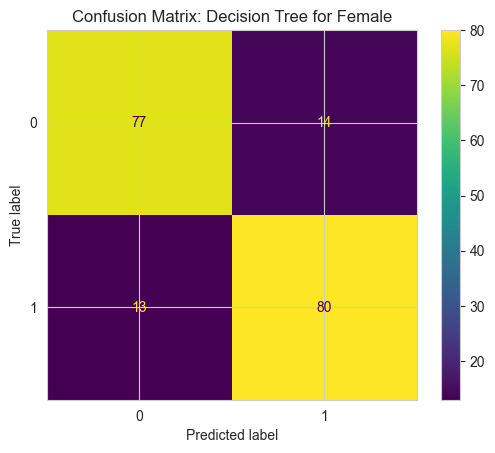

In [134]:

# Define a function to train and evaluate the Decision Tree model
def evaluate_decision_tree(data, gender_label):
    X = data.drop(columns=['Diagnosis', 'Gender'])  # Features
    y = data['Diagnosis']  # Target variable
    
    # Split the data into training and testing sets (75% training, 25% testing)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    
    # Initialize and train the Decision Tree model
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)
    
    # Make predictions and evaluate
    y_pred = tree.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    
    # Display results
    print(f"{gender_label} Decision Tree Accuracy:", accuracy)
    print(f"{gender_label} Decision Tree Classification Report:\n", class_report)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    ConfusionMatrixDisplay.from_estimator(tree, X_test, y_test)
    plt.title(f"Confusion Matrix: Decision Tree for {gender_label}")
    plt.show()

# Evaluate for Male
evaluate_decision_tree(male_data, "Male")

# Evaluate for Female
evaluate_decision_tree(female_data, "Female")


The Decision Tree model for males achieved an accuracy of approximately 87.43% with a balanced performance across both classes. The precision for Class 0 (absence of the condition) was 0.91, indicating a high level of correct identifications for negative cases. However, the model's precision for Class 1 (presence of the condition) was notably lower at 0.76, suggesting a struggle to correctly classify positive instances, as evidenced by the confusion matrix showing 12 false positives and 12 false negatives.

For females, the Decision Tree model showed a lower accuracy of about 85.33%, with both precision and recall remaining fairly consistent at 0.85 across classes. The confusion matrix illustrated that the model misclassified some instances, particularly for Class 0, with 14 false positives and 13 false negatives. This relatively lower performance compared to the male dataset indicates a difference in how the model interprets features based on gender.

Male Random Forest Accuracy: 0.9057591623036649
Male Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.94       140
           1       0.88      0.75      0.81        51

    accuracy                           0.91       191
   macro avg       0.90      0.85      0.87       191
weighted avg       0.90      0.91      0.90       191


<Figure size 800x600 with 0 Axes>

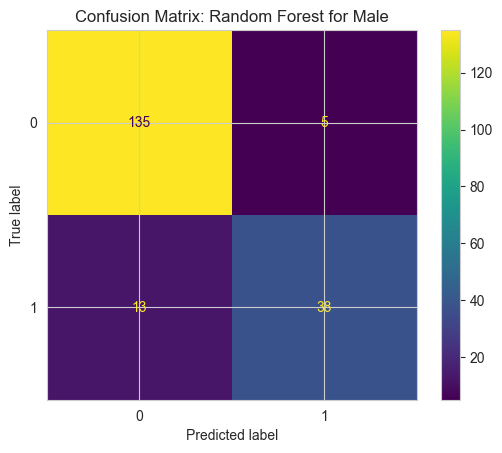

Female Random Forest Accuracy: 0.9130434782608695
Female Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91        91
           1       0.92      0.90      0.91        93

    accuracy                           0.91       184
   macro avg       0.91      0.91      0.91       184
weighted avg       0.91      0.91      0.91       184


<Figure size 800x600 with 0 Axes>

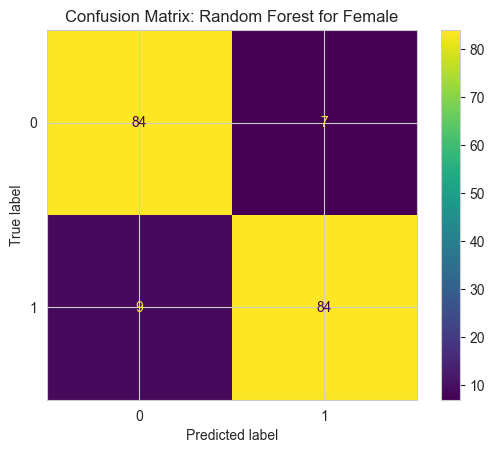

In [135]:

male_data = data[data['Gender'] == 0]  # Male data
female_data = data[data['Gender'] == 1]  # Female data

# Define a function to train and evaluate the Random Forest model
def evaluate_random_forest(data, gender_label):
    X = data.drop(columns=['Diagnosis', 'Gender'])  # Features
    y = data['Diagnosis']  # Target variable
    
    # Split the data into training and testing sets (75% training, 25% testing)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    
    # Initialize and train the Random Forest model
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train, y_train)
    
    # Make predictions and evaluate
    y_pred = rf_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    
    # Display results
    print(f"{gender_label} Random Forest Accuracy:", accuracy)
    print(f"{gender_label} Random Forest Classification Report:\n", class_report)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
    plt.title(f"Confusion Matrix: Random Forest for {gender_label}")
    plt.show()

# Evaluate for Male
evaluate_random_forest(male_data, "Male")

# Evaluate for Female
evaluate_random_forest(female_data, "Female")


The observed decrease in accuracy for both the Decision Tree and Random Forest models when evaluated separately by gender was minimal—generally around 2% or less. This suggests that while there are slight variations in performance, the overall effectiveness of both models remains relatively stable across the two gender groups.

**Decision Tree vs Random Forest**

The Random Forest model achieved an accuracy of 91.73%, while the Decision Tree model's accuracy was 87.20%. Furthermore, when it came to gender Random Forest model outperformed the Decision Tree model with accuracies of 90.58% (males) and 91.30% (females) compared to 87.43% (males) and 85.33% (females) for the Decision Tree. Random Forest performs best for classification tasks in diverse and potentially complex datasets, as it reliably improves predictive performance while effectively minimizing bias.